# Attention-based Unet for Segmentation

In this notebook, we present a summary of our work and the results obtained throughout the project. We explain our methodology, the models we implemented, and the performance we achieved.

<i>Note: The models were trained on Google Colab for faster computation, so the training logs do not appear directly in this notebook.</i>

In [1]:
# Import of the libraries and functions
%load_ext autoreload
%autoreload 2
from models import U_Net, AttU_Net
from train import train_2D, test_2D, test_3D
from utils import show_input_mask, compare_predictions_ground_truth, prepare_data, graph, predict_volume, load_slice, GradCAM, overlay_cam, overlay_cam_multi, saliency_map
from torch.utils.data import TensorDataset, DataLoader
import nibabel as nib
import matplotlib.pyplot as plt
import torch

We can start by showing an input image and an output mask to visualize the kind of results we want to obtain.

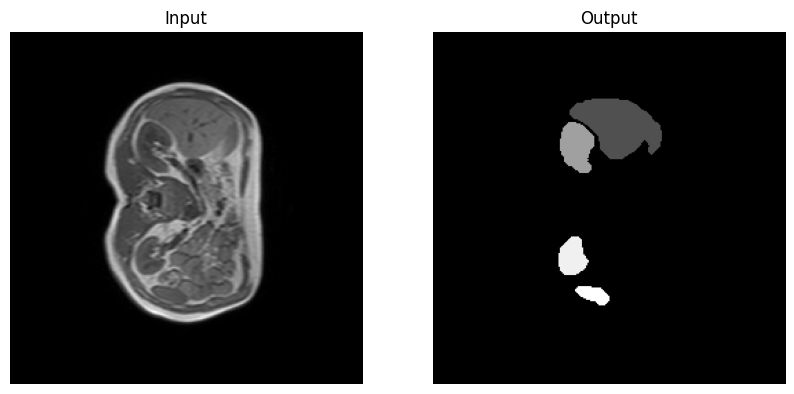

In [2]:
show_input_mask(input_path="data/MR-dataset/01-T1DUALin-src.nii.gz", output_path="data/MR-dataset/01-T1DUAL-mask.nii.gz", slice_idx=20)

## Training on different sets

At the very beginning, we were doing the split of the data directly in the training function :

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters

train_loss, validation_losses, test_loss = train_2D(
    model= U_Net(1, 5),
    name ="U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the U-Net were :

![](loss_images/U_Net_30_epochs.png)

Unfortunately, we no longer have the loss value for this U-Net on the test set. Moreover, even if we did, it wouldn’t be very informative, since we wouldn’t be able to compare it with the Attention U-Net’s loss due to differences in the test sets.

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters

train_loss, validation_losses, test_loss = train_2D(
    model= AttU_Net(1, 5),
    name ="Att_U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the Attention U-Net were :

![](loss_images/Att_U_Net_30.png)

And the loss on the test set was 0.1648. Therefore, we can think that the Attention U-Net is much better than the U-Net as the validation loss tends toward 0.1 for the Attention U-Net while it remains at 0.2 for the U-Net. However, as we did not use the same sets to compute the models and the losses, we can't make any conclusion at this point.

## Training on the same sets

In order to be able to compare the performances between the U-Net and the Attention U-Net, we define the training, validation and test set outside the training function such that we train the models with the same sets

In [2]:
# Training and test with random_seed = 43 for the split of the data

(X_train_tensor,
X_validation_tensor,
X_test_tensor,
y_train_tensor,
y_validation_tensor,
y_test_tensor,
X_test_3D,
y_test_3D) = prepare_data(train_size = 14, validation_size=2, random_seed = True, data_path="data")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

X_train.shape :  (461, 1, 256, 256)
X_validation.shape :  (56, 1, 256, 256)
X_test.shape :  (130, 1, 256, 256)


Then, we train the U-Net with the training, validation and test sets we defined in the previous cell.

In [ ]:
train_loss_u_net, validation_losses_u_net = train_2D(
    model=U_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="U_Net_weights30_V6",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

We also train the Attention U-Net with the same sets.

In [ ]:
train_loss_attention_u_net, validation_losses_attention_u_net = train_2D(
    model=AttU_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="Att_U_Net_weights30_V6",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

And we plot the loss figures to compare the performances of the two models.

![](loss_images/Loss_comparison_between_U-net_and_Attention-U-Net_V6.png)

We notice that the loss functions from the U-Net and the Attention U-Net are very close. We also see that the loss is generally higher for the Attention U-Net at the beginning of the training. The two losses tends towards the same limits and the difference of performances between the two models are not clearly visible.

To compare the performances of the two models, we can compute the combined loss we used during the training on the test sets.

In [ ]:
test_2D(U_Net(1,5), test_loader, "U_Net_weights30_V6")
test_2D(AttU_Net(1,5), test_loader, "Att_U_Net_weights30_V6")

We obtained :

Loss on test dataset for the U-Net: 0.1387

Dice per class on test dataset for the U-Net: [0.99449054 0.87784152 0.68303216 0.67318608 0.60799933]

Loss on test dataset for the Attention U-Net: 0.1402

Dice per class on test dataset for the Attention U-Net: [0.99382301 0.89200856 0.68617444 0.6615684  0.6146585]

When we compare the losses on the test dataset for the two models, we notice that we have a slightly higher loss for the Attention U-Net, which seems confusing as the Attention U-Net is supposed to improve the performance. We also not that some organs are better segmented with the Attention U-Net while others are better segmented with the classical U-Net. However, the performances of the two models are very close.

<i> Note : The loss used here is the combined loss defined in the losses file, which combine the 2D dice loss and the cross-entropy.

So what we notice is that we have better results for the Attention U-Net, based on the combined loss. However, as we work with 3D volumes, we want to test our models with 3D metrics such as 3D Dice Loss.

In [ ]:
test_3D(
    model = U_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "U_Net_weights30_V6"
)

We obtained : [0.9945, 0.9114, 0.8287, 0.8222, 0.7821]

In [ ]:
test_3D(
    model = AttU_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "Att_U_Net_weights30_V6"
)

We obtained : [0.9939, 0.9069, 0.8157, 0.8389, 0.7603]

Once again, the performances of the two models are very close but the U-Net still has better performance than the Attention U-Net.

## Visualisation of the volumes computed

In order to visualize the results obtained with our models, we show the input image, the target mask and the prediction we get.

<i> Note: For the visualizations in this section to render correctly, you may need to re-run the cells. Simply execute the first cell of the notebook (the one containing the imports), then run the subsequent cells. </i>

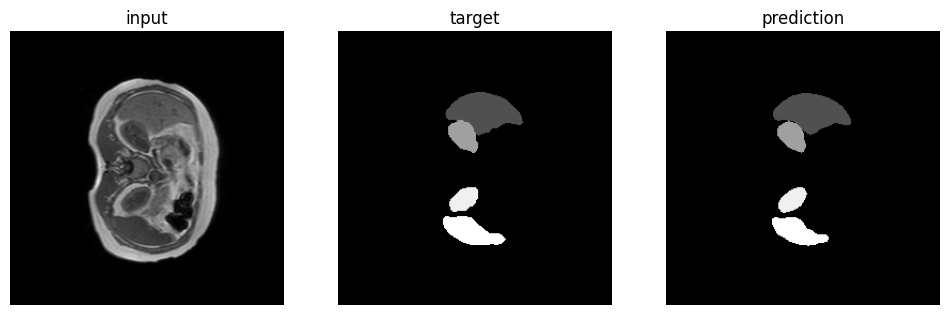

IntSlider(value=15, description='Slice', max=34)

In [5]:
compare_predictions_ground_truth(U_Net(1,5), "weights/U_Net_weights30_V6.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

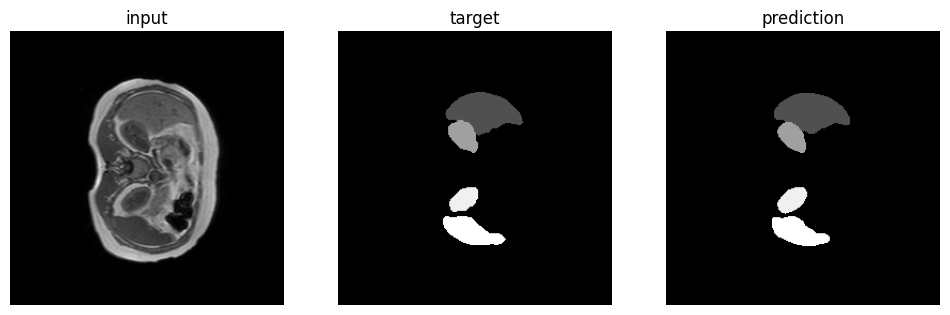

IntSlider(value=15, description='Slice', max=34)

In [ ]:
compare_predictions_ground_truth(AttU_Net(1,5), "weights/Att_U_Net_weights30_V6.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

Using the slider, we can observe that both models provide reasonably good volumetric predictions for the organs. However, we also notice that both the U-Net and Attention U-Net tend to struggle when two organs are very close or touching.

### Training of U-Net and Attention U-Net models over 50 epochs

We decided to train the models on more epochs to see if there will be a difference.

<i> Note: The following models have not been trained on the same sets as the previous ones. </i>

![Train loss](loss_images/Train_Loss_comparison_between_U-net_and_Attention-U-Net_50_epochs.png)
![Validation loss](loss_images/Validation_Loss_comparison_between_U-net_and_Attention-U-Net_50_epochs.png)


The loss curves show that there is no significant difference between the loss at epoch 50 and the loss at epoch 30. This suggests that continuing the training further is not particularly useful, as the models have already reached their optimal performance.

In [13]:
test_loss,dice_classes = test_2D(
    model=U_Net(1, 5),
    test_loader=test_loader,
    name ="models/U_Net_weights50"
)
#Loss on test dataset: 0.1841
#Dice per class on test dataset: [0.99417681 0.86107182 0.56421426 0.53450103 0.5273771 ]

Loss on test dataset: 0.1841
Dice per class on test dataset: [0.99417681 0.86107182 0.56421426 0.53450103 0.5273771 ]


In [14]:
test_loss,dice_classes = test_2D(
    model=AttU_Net(1, 5),
    test_loader=test_loader,
    name ="models/Att_U_Net_weights50"
)
#Loss on test dataset: 0.1621
#Dice per class on test dataset: [0.99505883 0.87836151 0.53795041 0.61200625 0.60462299]

#Loss on test dataset: 0.1621
Dice per class on test dataset: [0.99505883 0.87836151 0.53795041 0.61200625 0.60462299]


In [ ]:
test_3D(
    model = U_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "models/U_Net_weights50"
)

#tensor([0.9943, 0.9125, 0.7876, 0.7674, 0.7605])

In [ ]:
test_3D(
    model = AttU_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "models/Att_U_Net_weights50"
)

#tensor([0.9950, 0.9150, 0.7191, 0.8026, 0.8353])

tensor([0.9950, 0.9150, 0.7191, 0.8026, 0.8353])

When examining the Dice scores on the 3D volumes, we observe that the Attention U-Net achieves better performance on 3 out of the 4 organs. This suggests that incorporating attention mechanisms is beneficial and leads to improved segmentation accuracy for this task.

It is important to note, however, that the two models were trained using different data splits. With the current split, the Attention U-Net outperforms the U-Net, whereas with the split used in earlier experiments, the opposite trend was observed. This highlights the sensitivity of both models to the data partition and suggests that the comparison should be interpreted with caution.

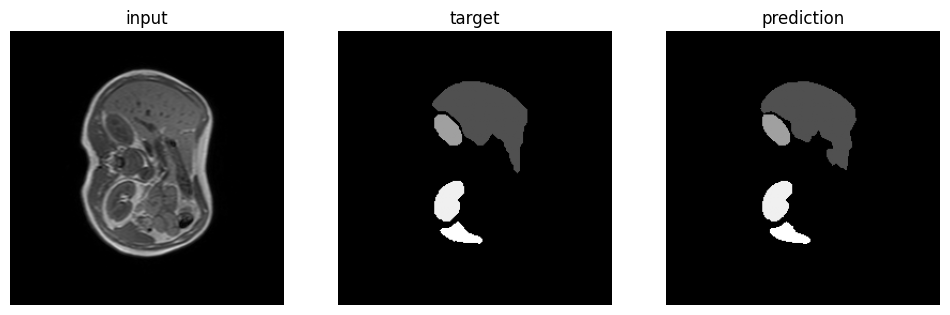

IntSlider(value=25, description='Slice', max=34)

In [23]:
compare_predictions_ground_truth(U_Net(1,5), "models/U_Net_weights50.pth", "data/MR-dataset/01-T1DUALin-src.nii.gz", "data/MR-dataset/01-T1DUAL-mask.nii.gz")

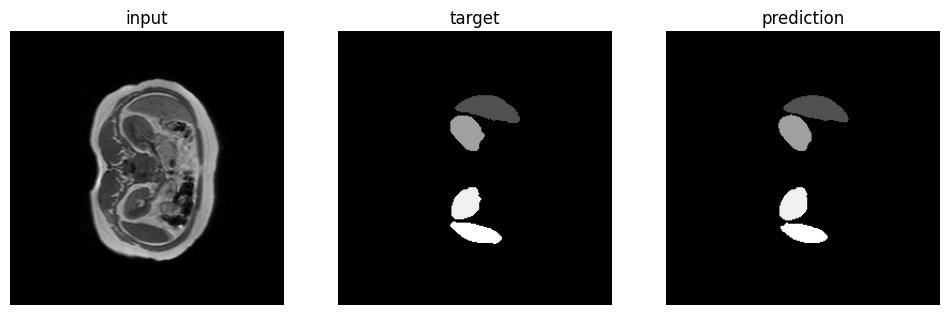

IntSlider(value=12, description='Slice', max=34)

In [ ]:
compare_predictions_ground_truth(AttU_Net(1,5), "models/Att_U_Net_weights50.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

## Visualization of saliency maps

To visualize the regions that contribute most to the organ segmentation, we display the saliency maps obtained by computing the gradients of the model’s output with respect to the input image.

We used two methods to compute the saliency maps: a classic one using the gradients of the model's output with respect to the input image, and another one using GradCam.

In [ ]:
# Compute of the predicted volume

nifti_out, volume = predict_volume(U_Net(1,5), "weights/U_Net_weights30_V6.pth", "data/MR-dataset/01-T1DUALin-src.nii.gz")

In [ ]:
# Save of the predicted volume

save_path = "reconstructed_volumes/predicted_mask_01-T1DUAL_U_Net.nii.gz"
nib.save(nifti_out, save_path)

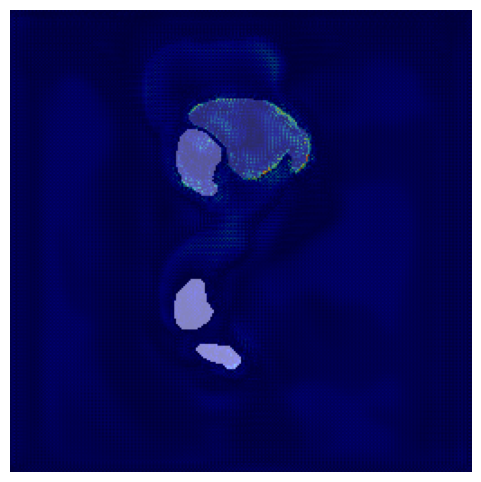

In [119]:
# Show of the saliency map

model = U_Net(1,5)
model.load_state_dict(torch.load("weights/U_Net_weights30_V6.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUALin-src.nii.gz", 29)

grad = saliency_map(model, image, class_idx=1)

overlay_cam(image, grad)

When we look at the saliency map, we can see that the 

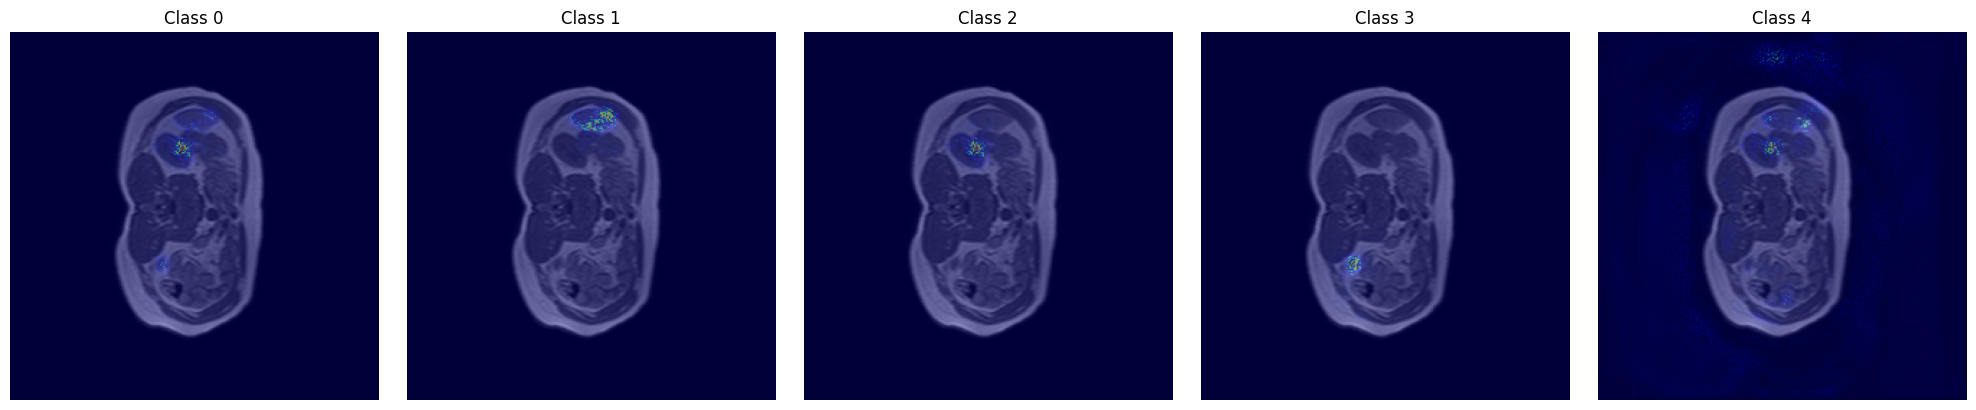

In [32]:
# Calcul des saliency maps pour les 5 classes
cams = []
for class_idx in range(5):
    grad = saliency_map(model, image, class_idx=class_idx)
    cams.append(grad)

# Affichage
overlay_cam_multi(image, cams, titles=[f"Class {i}" for i in range(5)])

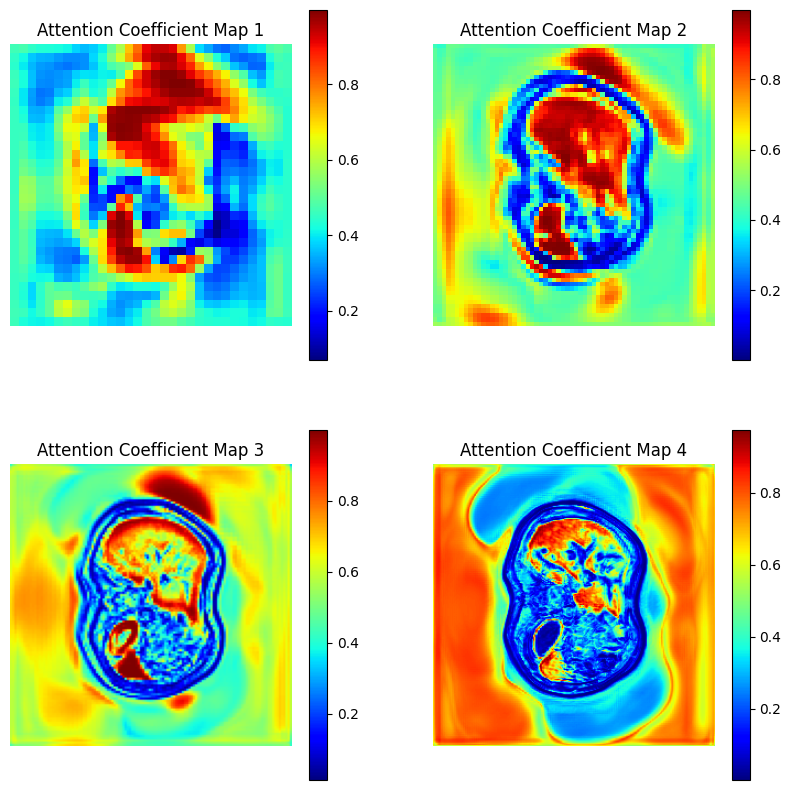

In [120]:
output, attention_coeffs = model(image, return_attentions=True)

plt.figure(figsize=(10,10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(attention_coeffs[i][0,0].detach().numpy(), cmap='jet')
    plt.title(f'Attention Coefficient Map {i+1}')
    plt.axis('off')
    plt.colorbar()

When we look at the saliency maps for each of the class, we see that the organs are well 

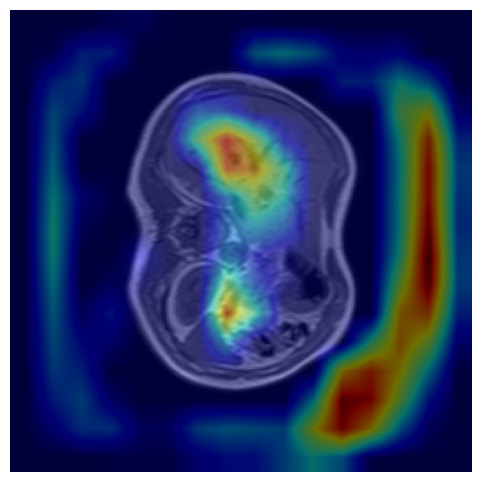

In [77]:
model = U_Net(1,5)
model.load_state_dict(torch.load("models/U_Net_weights50.pth", map_location = torch.device('cpu')))

target_layer = model.Conv5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/01-T1DUALin-src.nii.gz", 29)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=1)

overlay_cam(image, heatmap)

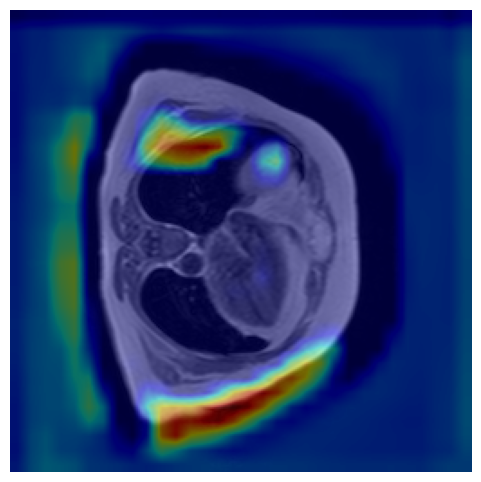

In [8]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("weights/Att_U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

target_layer = model.Att5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/04-T1DUALin-src.nii.gz", 20)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=2)

overlay_cam(image, heatmap)

In [71]:
nifti_out, volume = predict_volume(AttU_Net(1,5), "models/attU_Net_weights100.pth","data/MR-dataset/01-T1DUALin-src.nii.gz")

<class 'numpy.ndarray'>
(35, 256, 256)


In [6]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("weights/U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUAL-mask.nii.gz", 20)

grad = saliency_map(model, image, class_idx=3)

overlay_cam(image, grad)

RuntimeError: Error(s) in loading state_dict for AttU_Net:
	Missing key(s) in state_dict: "Att5.W_g.0.weight", "Att5.W_g.0.bias", "Att5.W_g.1.weight", "Att5.W_g.1.bias", "Att5.W_g.1.running_mean", "Att5.W_g.1.running_var", "Att5.W_x.0.weight", "Att5.W_x.0.bias", "Att5.W_x.1.weight", "Att5.W_x.1.bias", "Att5.W_x.1.running_mean", "Att5.W_x.1.running_var", "Att5.psi.0.weight", "Att5.psi.0.bias", "Att5.psi.1.weight", "Att5.psi.1.bias", "Att5.psi.1.running_mean", "Att5.psi.1.running_var", "Att4.W_g.0.weight", "Att4.W_g.0.bias", "Att4.W_g.1.weight", "Att4.W_g.1.bias", "Att4.W_g.1.running_mean", "Att4.W_g.1.running_var", "Att4.W_x.0.weight", "Att4.W_x.0.bias", "Att4.W_x.1.weight", "Att4.W_x.1.bias", "Att4.W_x.1.running_mean", "Att4.W_x.1.running_var", "Att4.psi.0.weight", "Att4.psi.0.bias", "Att4.psi.1.weight", "Att4.psi.1.bias", "Att4.psi.1.running_mean", "Att4.psi.1.running_var", "Att3.W_g.0.weight", "Att3.W_g.0.bias", "Att3.W_g.1.weight", "Att3.W_g.1.bias", "Att3.W_g.1.running_mean", "Att3